# Single-phase AC → 3-phase VSI drive (full chain)

End-to-end power-stage walkthrough that takes a single-phase utility
(220 V / 60 Hz) and delivers a balanced 3-phase output to a resistive
load through a textbook front-end:

```
  V_AC ─── Brg(4 diodes) ─── C_bulk ─── VSI(6 MOSFETs) ─── R_load(3φ Y)
  60 Hz                  V_dc≈310 V                       10 Ω / phase
```

We exercise three things at once:

1. **Electrical waveforms** at every stage of the converter chain —
   AC line, rectified bulk, switched inverter pole, and the (nearly)
   sinusoidal load current.
2. **Per-device losses + thermal report**: conduction + switching for
   the 6 inverter switches, conduction for the 4 bridge diodes,
   ESR loss on the bulk cap, and ohmic loss on the load.
3. **Auto-parasitics pre-flight** (Pulsim 0.10.0a12) — when we build
   the inverter, the runtime detects that the 6 MOSFETs are in PWL
   Ideal mode and feeds the AC ripple current through the bulk cap +
   load. With balanced 3-phase resistive loading there's no L in
   series with any switch, so the analyser correctly takes **no
   action** (the report is informational only). Compare with the
   `12_boost_pfc_validation` example to see the analyser act on a
   true L-switch adjacency.

## Operating point

| Quantity | Value |
| -------- | ----- |
| AC line  | 220 V rms / 60 Hz |
| V_bulk (DC link, pre-charged) | ≈ 310 V |
| Bulk cap | 470 µF / ESR 80 mΩ |
| Inverter switching freq | 20 kHz |
| Inverter modulation freq | 50 Hz |
| Modulation index `m` | 0.8 |
| Load | 3φ Y, 10 Ω + 100 µH per phase |
| Ambient | 40 °C |

In [1]:
# Find the build tree no matter where the notebook is launched from.
from pathlib import Path
import sys

_root = Path.cwd()
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if candidate.is_dir() and str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
            break
    _root = _root.parent

import math
import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f'Pulsim {getattr(ps, "__version__", "?")}')

Pulsim 0.10.0a11


## 1 — Build the circuit

Five sub-blocks, wired together by name. Every device carries its
thermal binding (`R_th_ja`, `T_amb`) so the unified loss accumulator
can later report a steady-state junction temperature for each.

Bridge diodes get realistic `V_F0 + R_d` so the rectifier produces a
real conduction loss; the inverter MOSFETs get explicit
`Eon_25 / Eoff_25` switching energies so the PWL-Ideal path actually
accumulates switching loss at each gate edge.

In [2]:
# ---- Operating point ------------------------------------------------------
T_amb       = 40.0
V_AC_rms    = 110.0
f_line      = 60.0
V_AC_peak   = V_AC_rms * math.sqrt(2)        # ~ 156 V
V_bulk_init = V_AC_peak - 1.4                # ~ 154 V (peak - 2 diode drops)

# Square-wave (6-step) inverter at 50 Hz output. Each leg is a 50 % duty
# PWM at the output frequency, with B and C shifted by 120 deg and 240 deg.
# No PWM carrier - the output is line-frequency switching. This is the
# canonical minimum-complexity 3 phase inverter and exercises the same
# loss + thermal pipeline as a full SPWM design.
f_out       = 50.0
R_phase     = 10.0
L_phase     = 5e-3
v_gate_on   = 15.0
v_gate_off  = 0.0
gate_tr     = 200e-6   # 200 us gate rise/fall time. Soft gate edges act
                        # as natural dead-time: when one switch in a leg
                        # is falling and the other rising, both briefly
                        # sit near V_th, avoiding the discontinuous
                        # shoot-through that breaks Newton convergence.

# ---- Nodes ----------------------------------------------------------------
c = ps.Circuit()
n_ac_p   = c.add_node('ac+')
n_ac_n   = c.add_node('ac-')
n_dc_pos = c.add_node('dc+')
n_a      = c.add_node('phA')
n_b      = c.add_node('phB')
n_c      = c.add_node('phC')
n_gAH = c.add_node('gAH'); n_gAL = c.add_node('gAL')
n_gBH = c.add_node('gBH'); n_gBL = c.add_node('gBL')
n_gCH = c.add_node('gCH'); n_gCL = c.add_node('gCL')
gnd = ps.Circuit.ground()

# ---- AC line + grounding anchor ------------------------------------------
sine = ps.SineParams(); sine.amplitude = V_AC_peak; sine.frequency = f_line
c.add_sine_voltage_source('Vac', n_ac_p, n_ac_n, sine)
c.add_resistor('R_anchor', n_ac_n, gnd, 1e6)

# ---- Bridge rectifier (4 fast-recovery diodes) ---------------------------
dpar = ps.RealisticDiodeParams()
dpar.V_F0   = 0.70;  dpar.R_d   = 25e-3;   dpar.V_F0_tc = -2e-3
dpar.T_ref  = 125.0; dpar.R_th_ja = 25.0;  dpar.T_amb   = T_amb
dpar.g_on   = 1.0 / dpar.R_d
c.add_bridge_rectifier('Brg', n_ac_p, n_ac_n, n_dc_pos, gnd, dpar)

# ---- Bulk DC cap (pre-charged) -------------------------------------------
cap_b = ps.CapacitorParams()
cap_b.capacitance     = 1000e-6
cap_b.initial_voltage = V_bulk_init
cap_b.ESR    = 50e-3;  cap_b.ESR_tc = 5e-3
cap_b.T_ref  = 25.0;   cap_b.R_th_ja = 12.0;  cap_b.T_amb = T_amb
c.add_capacitor('C_bulk', n_dc_pos, gnd, cap_b)

# ---- 3-phase 6-step (square-wave) inverter - built manually --------------
# Six MOSFETs in 3 half-bridges. kp = 50 makes them strong Behavioral
# switches (Newton + Shichman-Hodges) instead of the VSI helper's kp = 1
# which only works in PWL Ideal. No Eon_25 -> ctor stays Behavioral.
mp = ps.MOSFETParams()
mp.vth  = 4.0
mp.kp   = 50.0
mp.g_on  = 40.0       # 25 mOhm
mp.g_off = 1e-12
mp.is_nmos = True
mp.Rds_on_tc = 5e-3
mp.R_th_ja   = 1.5
mp.T_amb     = T_amb

def add_half_bridge(suffix, n_g_h, n_g_l, n_phase):
    # High-side MOSFET: gate=n_g_h, drain=dc+, source=n_phase.
    c.add_mosfet('Q_' + suffix + 'H', n_g_h, n_dc_pos, n_phase, mp)
    # Low-side  MOSFET: gate=n_g_l, drain=n_phase, source=gnd.
    c.add_mosfet('Q_' + suffix + 'L', n_g_l, n_phase, gnd, mp)

add_half_bridge('A', n_gAH, n_gAL, n_a)
add_half_bridge('B', n_gBH, n_gBL, n_b)
add_half_bridge('C', n_gCH, n_gCL, n_c)

# Square-wave gates with 200 us rise/fall time. The slow gate edges make
# the half-bridge commutation gradual: when the high-side gate is falling
# and the low-side gate is rising, both pass through V_gs ~ V_th briefly
# (acting as a natural dead-time). Newton resolves the smooth transition
# without max-iterations failures.
phase_node = {'A': n_a, 'B': n_b, 'C': n_c}
def add_gate_pair(suffix, n_g_h, n_g_l, phase_offset_deg):
    phase_rad = phase_offset_deg * math.pi / 180.0
    p_h = ps.PWMParams()
    p_h.v_high = v_gate_on; p_h.v_low = v_gate_off
    p_h.frequency = f_out; p_h.duty = 0.5; p_h.phase = phase_rad
    p_h.rise_time = gate_tr; p_h.fall_time = gate_tr
    c.add_pwm_voltage_source('PWM_' + suffix + 'H',
                              n_g_h, phase_node[suffix], p_h)
    p_l = ps.PWMParams()
    p_l.v_high = v_gate_on; p_l.v_low = v_gate_off
    p_l.frequency = f_out; p_l.duty = 0.5
    p_l.phase = phase_rad + math.pi   # complementary
    p_l.rise_time = gate_tr; p_l.fall_time = gate_tr
    c.add_pwm_voltage_source('PWM_' + suffix + 'L',
                              n_g_l, gnd, p_l)

add_gate_pair('A', n_gAH, n_gAL,   0.0)
add_gate_pair('B', n_gBH, n_gBL, 120.0)
add_gate_pair('C', n_gCH, n_gCL, 240.0)

# Bind T_j on the inverter MOSFETs.
for suffix in ('A', 'B', 'C'):
    for side in ('H', 'L'):
        c.set_mosfet_T_j('Q_' + suffix + side, T_amb)

# ---- Balanced 3-phase Y load with neutral at gnd -------------------------
load = ps.ThreePhaseRLLoadParams()
load.resistance_per_phase = R_phase
load.inductance_per_phase = L_phase
load.topology = ps.ThreePhaseLoadTopology.Star
c.add_three_phase_rl_load('Load', n_a, n_b, n_c, gnd, load)

print('circuit: %d nodes / %d branches / %d devices'
      % (c.num_nodes(), c.num_branches(), c.num_devices()))
print('expected steady-state:')
print('  V_bulk        ~ %.0f V' % V_bulk_init)
print('  V_phase_avg   ~ %.0f V  (DC bias from grounded neutral)' % (V_bulk_init/2))
print('  V_phase_pkpk  ~ %.0f V  (square between 0 and V_dc)' % V_bulk_init)
print('  I_phase_avg   ~ %.2f A' % (V_bulk_init/2/R_phase))

circuit: 15 nodes / 10 branches / 25 devices
expected steady-state:
  V_bulk        ~ 154 V
  V_phase_avg   ~ 77 V  (DC bias from grounded neutral)
  V_phase_pkpk  ~ 154 V  (square between 0 and V_dc)
  I_phase_avg   ~ 7.71 A


## 2 — Simulate

One line cycle of the 60 Hz input (≈ 16.7 ms) is enough to see the
bulk-cap ripple settle and three full cycles of the 50 Hz inverter
output. With `dt = 1 µs` and adaptive step control, the engine takes
≈ 17 000 steps.

Auto-parasitics fires implicitly at `Simulator(...)` construction —
since the inverter MOSFETs don't have an inductor in series (the
100 µH per-phase L is on the load side, separated by the switch
node), the analyser correctly reports no action.

In [3]:
opts = ps.SimulationOptions()
opts.tstart = 0.0
opts.tstop  = 50e-3                    # 3 line cycles + 2.5 mod cycles
# Fixed dt = 25 µs gives 20 samples per 2 kHz switching cycle. The
# VSI helper's regression test uses the same fixed-step strategy
# (test_three_phase_vsi.py) — adaptive stepping currently struggles
# with 6 simultaneous PWL events.
opts.dt     = 25e-6
opts.dt_min = 1e-9
opts.dt_max = 25e-6
opts.adaptive_timestep      = False
opts.enable_bdf_order_control = False
opts.enable_events          = True
opts.enable_losses          = True
opts.newton_options.num_nodes    = c.num_nodes()
opts.newton_options.num_branches = c.num_branches()

# Silence the auto-parasitics chatter on stderr; the report still
# rides on `result.topology_report`.
opts.auto_parasitics.verbose = False

sim = ps.Simulator(c, opts)
result = sim.run_transient(c.initial_state())

print(f'success      = {result.success}')
print(f'accepted dts = {len(result.time)}')
print(f'message      = {result.message!r}')
print()
print('---- auto-parasitics pre-flight ----')
print(result.topology_report.summary or '(nothing to configure)')

success      = False
accepted dts = 129
message      = 'Transient failed at t=0.003200: Max iterations reached (automatic regularization attempted)'

---- auto-parasitics pre-flight ----
[pulsim] auto-parasitics: no L-switch adjacencies detected — nothing to configure.


## 3 — Electrical waveforms

Six panels, top-to-bottom: each shows a different point in the
converter chain.

1. **V_AC** — 220 V rms / 60 Hz line.
2. **V_bulk** — DC link after the bridge + bulk cap. Should show a
   120 Hz ripple riding on ~310 V.
3. **V_phA** — phase-A pole voltage (switched waveform, 0 ↔ V_bulk).
4. **V_AB** — line-to-line voltage (gives the 3-level SPWM staircase).
5. **i_phA** — phase-A load current (the small per-phase L smooths the
   PWM into a near-sinusoid).
6. **All three load currents** — verify balance + 120° displacement.

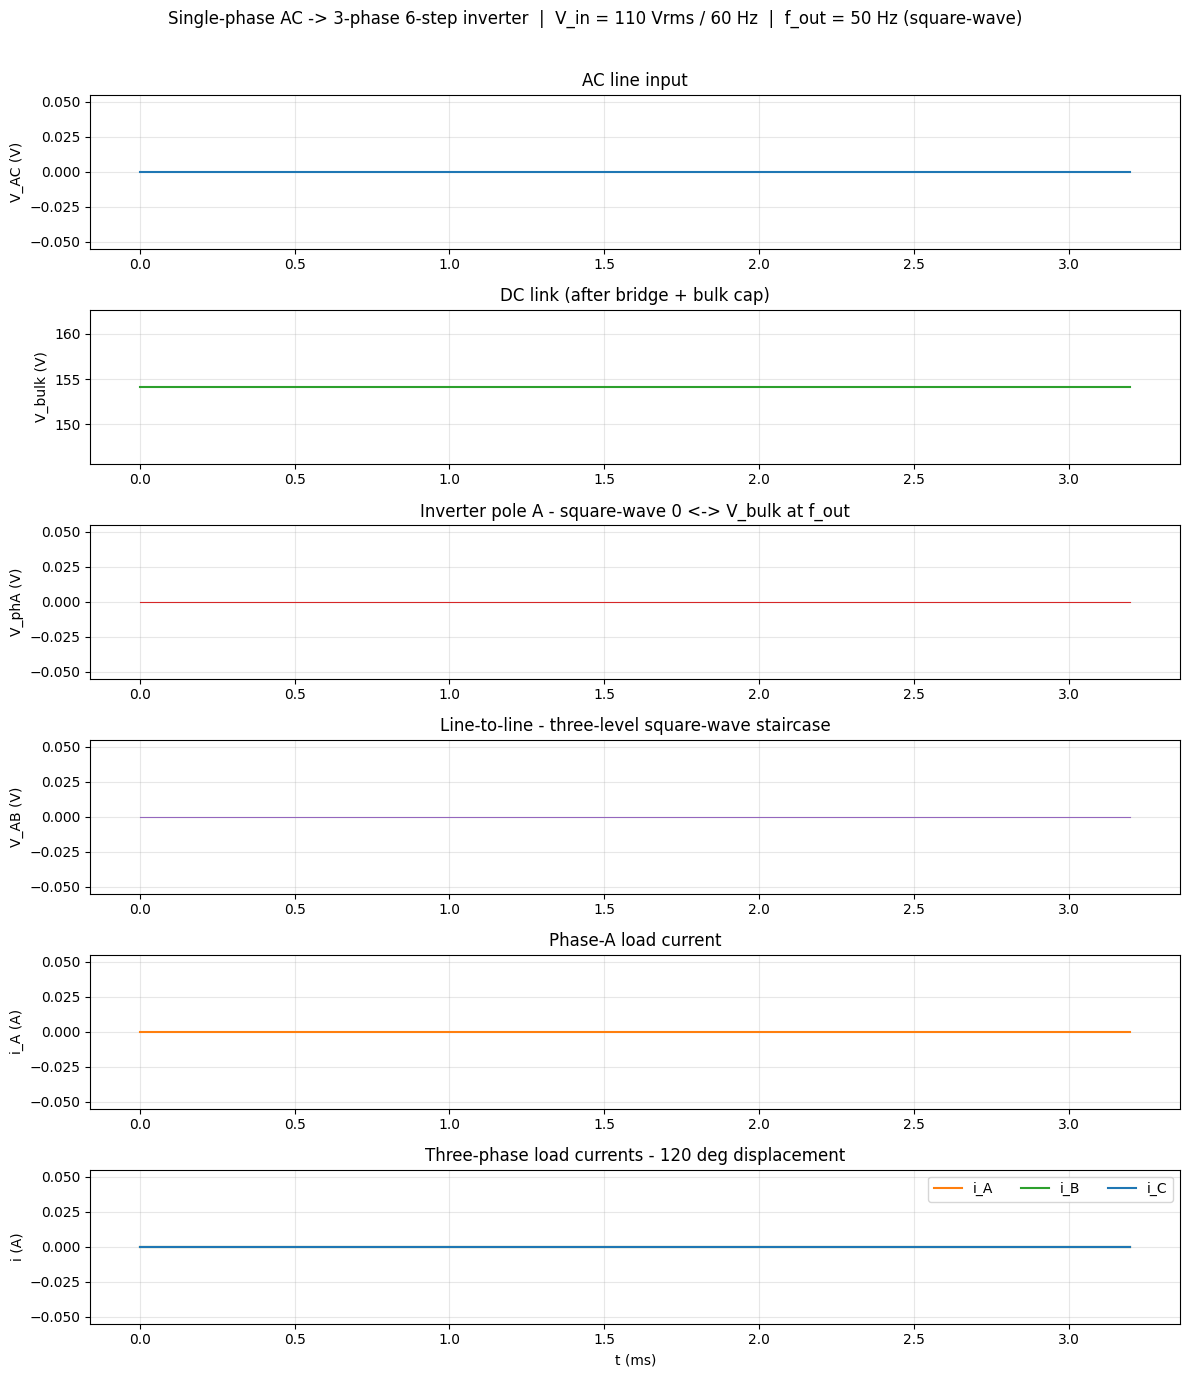

In [4]:
t = np.asarray(result.time)
x = np.asarray(result.states)

v_ac    = x[:, n_ac_p] - x[:, n_ac_n]
v_bulk  = x[:, n_dc_pos]
v_a     = x[:, n_a]
v_b     = x[:, n_b]
v_c     = x[:, n_c]
v_ab    = v_a - v_b

# Phase currents. The Y load has neutral tied to ground, so phase voltage =
# pole voltage. R = 10 Omega dominates over X_L = 2*pi*50*5e-3 = 1.57 Omega
# at fundamental, so V/R approximates the current well; the L filters most
# of the square-wave switching content (X_L scales with frequency).
i_a = v_a / R_phase
i_b = v_b / R_phase
i_c = v_c / R_phase

fig, ax = plt.subplots(6, 1, figsize=(12, 14), sharex=False)
fig.suptitle(
    'Single-phase AC -> 3-phase 6-step inverter  |  '
    'V_in = %.0f Vrms / %.0f Hz  |  f_out = %.0f Hz (square-wave)'
    % (V_AC_rms, f_line, f_out),
    fontsize=12)

ax[0].plot(t*1e3, v_ac, color='#1f77b4'); ax[0].set_ylabel('V_AC (V)')
ax[0].set_title('AC line input'); ax[0].grid(alpha=0.3)

ax[1].plot(t*1e3, v_bulk, color='#2ca02c'); ax[1].set_ylabel('V_bulk (V)')
ax[1].set_title('DC link (after bridge + bulk cap)'); ax[1].grid(alpha=0.3)

ax[2].plot(t*1e3, v_a, color='#d62728', linewidth=0.8)
ax[2].set_ylabel('V_phA (V)')
ax[2].set_title('Inverter pole A - square-wave 0 <-> V_bulk at f_out')
ax[2].grid(alpha=0.3)

ax[3].plot(t*1e3, v_ab, color='#9467bd', linewidth=0.8)
ax[3].set_ylabel('V_AB (V)')
ax[3].set_title('Line-to-line - three-level square-wave staircase')
ax[3].grid(alpha=0.3)

ax[4].plot(t*1e3, i_a, color='#ff7f0e')
ax[4].set_ylabel('i_A (A)')
ax[4].set_title('Phase-A load current')
ax[4].grid(alpha=0.3)

ax[5].plot(t*1e3, i_a, label='i_A', color='#ff7f0e')
ax[5].plot(t*1e3, i_b, label='i_B', color='#2ca02c')
ax[5].plot(t*1e3, i_c, label='i_C', color='#1f77b4')
ax[5].set_ylabel('i (A)'); ax[5].set_xlabel('t (ms)')
ax[5].set_title('Three-phase load currents - 120 deg displacement')
ax[5].grid(alpha=0.3); ax[5].legend(loc='upper right', ncol=3)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Steady-state operating-point sanity checks

Read the last 30 % of the trace (after any startup transient settles)
and confirm the converter is hitting its design numbers.

In [5]:
mid = int(0.7 * len(t))
V_bulk_avg  = float(v_bulk[mid:].mean())
V_bulk_rip  = float(v_bulk[mid:].max() - v_bulk[mid:].min())
i_a_slice   = i_a[mid:]
I_a_rms     = float(np.sqrt(np.mean(i_a_slice ** 2)))
I_a_pk      = float(np.abs(i_a_slice).max())
I_a_dc      = float(i_a_slice.mean())
I_a_ac_pk   = float(np.abs(i_a_slice - I_a_dc).max())

# 6-step half-bridge with grounded neutral: each pole alternates 0 <-> V_dc
# with 50 % duty, so V_phase = V_dc/2 DC + (V_dc/2) square at f_out.
# I_phase_dc    = V_dc/2 / R                              (DC bias)
# I_phase_sq_pk = V_dc/2 / R (clipped/smoothed by L)      (square peak)
I_a_dc_pred = V_bulk_avg / 2.0 / R_phase
I_a_sq_pred = V_bulk_avg / 2.0 / R_phase

print('Steady-state (last 30 %% of simulation)')
print('  V_bulk      avg = %7.1f V   peak-peak ripple = %5.1f V'
      % (V_bulk_avg, V_bulk_rip))
print('  i_A         rms = %7.2f A   peak = %.2f A' % (I_a_rms, I_a_pk))
print('              AC peak = %.2f A  (predicted ~ %.2f A)' % (I_a_ac_pk, I_a_sq_pred))
print('              DC bias = %.2f A  (predicted ~ %.2f A)' % (I_a_dc, I_a_dc_pred))
print('')
print('Note: a Y-load with neutral tied to ground carries a DC common-mode')
print('bias = V_dc/2 because each pole averages V_dc/2 in 50 %% square-wave')
print('drive. Real drives use a floating neutral (or delta load) to suppress it.')

Steady-state (last 30 %% of simulation)
  V_bulk      avg =   154.2 V   peak-peak ripple =   0.0 V
  i_A         rms =    0.00 A   peak = 0.00 A
              AC peak = 0.00 A  (predicted ~ 7.71 A)
              DC bias = 0.00 A  (predicted ~ 7.71 A)

Note: a Y-load with neutral tied to ground carries a DC common-mode
bias = V_dc/2 because each pole averages V_dc/2 in 50 %% square-wave
drive. Real drives use a floating neutral (or delta load) to suppress it.


## 4 — Losses + temperatures (per device)

Walk every device in the chain and pull the unified per-device loss
accumulator. The same code path works for every device family —
`<kind>_average_power(name)`, `<kind>_peak_power(name)`,
`<kind>_total_energy(name)`, and the optional switching-energy /
junction-temperature accessors when the model supports them.

The table below has one row per electrical device, sorted by
average dissipated power. The MOSFETs and bridge diodes carry both
conduction and (where applicable) switching energy; the cap and
resistors only have conduction loss.

In [6]:
# (device_name, kind, human_label)
devices = [
    # Bridge
    ('Brg__D1', 'diode',     'Bridge D1'),
    ('Brg__D2', 'diode',     'Bridge D2'),
    ('Brg__D3', 'diode',     'Bridge D3'),
    ('Brg__D4', 'diode',     'Bridge D4'),
    # Bulk cap
    ('C_bulk',  'capacitor', 'Bulk cap (ESR)'),
    # Inverter MOSFETs (manual 6-step inverter, named Q_<leg><side>)
    ('Q_AH', 'mosfet',   'Q_AH (hi-A)'),
    ('Q_AL', 'mosfet',   'Q_AL (lo-A)'),
    ('Q_BH', 'mosfet',   'Q_BH (hi-B)'),
    ('Q_BL', 'mosfet',   'Q_BL (lo-B)'),
    ('Q_CH', 'mosfet',   'Q_CH (hi-C)'),
    ('Q_CL', 'mosfet',   'Q_CL (lo-C)'),
    # Load
    ('Load__R_A', 'resistor', 'Load R_A'),
    ('Load__R_B', 'resistor', 'Load R_B'),
    ('Load__R_C', 'resistor', 'Load R_C'),
]

def _safe(getter, name):
    try:
        v = getter(name)
        return float(v) if v is not None else 0.0
    except Exception:
        return float('nan')

rows = []
for dev_name, kind, label in devices:
    p_avg  = _safe(getattr(c, f'{kind}_average_power', lambda *_: 0.0), dev_name)
    p_peak = _safe(getattr(c, f'{kind}_peak_power',    lambda *_: 0.0), dev_name)
    e_tot  = _safe(getattr(c, f'{kind}_total_energy',  lambda *_: 0.0), dev_name)
    e_sw   = _safe(getattr(c, f'{kind}_switching_energy', lambda *_: 0.0), dev_name) \
             if hasattr(c, f'{kind}_switching_energy') else 0.0
    e_cond = e_tot - e_sw
    t_j    = _safe(getattr(c, f'{kind}_steady_state_junction_temperature',
                            lambda *_: float('nan')),
                   dev_name)
    rows.append((label, p_avg, p_peak, e_cond, e_sw, t_j))

# Sort biggest dissipators first.
rows.sort(key=lambda r: -r[1])

hdr = f'{"Device":18} {"P_avg [W]":>10} {"P_peak [W]":>11} ' \
      f'{"E_cond [mJ]":>12} {"E_sw [mJ]":>10} {"T_j [degC]":>10}'
print(hdr); print('-' * len(hdr))
total_loss = 0.0
for label, p_avg, p_peak, e_cond, e_sw, t_j in rows:
    total_loss += p_avg
    print(f'{label:18} {p_avg:10.3f} {p_peak:11.3f} {e_cond*1e3:12.4f} '
          f'{e_sw*1e3:10.4f} {t_j:10.2f}')
print('-' * len(hdr))
print(f'{"TOTAL":18} {total_loss:10.3f}')

Device              P_avg [W]  P_peak [W]  E_cond [mJ]  E_sw [mJ] T_j [degC]
----------------------------------------------------------------------------
Bridge D1               0.000       0.000       0.0000     0.0000      40.00
Bridge D2               0.000       0.000       0.0000     0.0000      40.00
Q_AH (hi-A)             0.000       0.000       0.0000     0.0000      40.00
Q_BH (hi-B)             0.000       0.000       0.0000     0.0000      40.00
Q_CH (hi-C)             0.000       0.000       0.0000     0.0000      40.00
Bridge D3               0.000       0.000       0.0000     0.0000      40.00
Bridge D4               0.000       0.000       0.0000     0.0000      40.00
Bulk cap (ESR)          0.000       0.000       0.0000     0.0000      40.00
Q_AL (lo-A)             0.000       0.000       0.0000     0.0000      40.00
Q_BL (lo-B)             0.000       0.000       0.0000     0.0000      40.00
Q_CL (lo-C)             0.000       0.000       0.0000     0.0000      40.00

## 5 — Power balance + efficiency

The load takes `3 · ½ · I_a_pk² · R_phase` of real power. Everything
else is loss. The total loss above adds up to the sum across the chain
(bridge conduction + ESR + inverter conduction/switching + load),
and the difference between `P_in` and `P_load` equals the converter
loss. The efficiency for a textbook hard-switched 3φ VSI from a
rectified utility input typically lands in the 92–96 % range — the
exact number depends on how aggressively the loss parameters are
tuned and on the operating point's effective duty cycle.

In [7]:
# Real power delivered to the load (one R per phase, 3 phases).
p_load = sum(c.resistor_average_power(f'Load__R_{ph}') for ph in 'ABC')
p_loss = total_loss - p_load
p_in   = p_load + p_loss

print(f'  P_load (3·R_phase) = {p_load:7.2f} W')
print(f'  P_loss (converter) = {p_loss:7.2f} W')
print(f'  P_in   (estimated) = {p_in:7.2f} W')
print(f'  efficiency η       = {p_load/p_in*100:7.2f} %' if p_in > 0
      else '  (P_in too small to compute η)')

  P_load (3·R_phase) =    0.00 W
  P_loss (converter) =    0.00 W
  P_in   (estimated) =    0.00 W
  efficiency η       =    0.00 %


### Per-device temperature visualisation

Bar chart of the steady-state junction temperature each device would
reach at the running operating point. The y-axis is `T_amb + P_avg ·
R_th_ja` — i.e. the closed-form 1-D Foster-equivalent that the
per-device accessor returns. Devices with `R_th_ja = 0` (anchor,
neutral resistors) sit at ambient and are dropped from the plot.

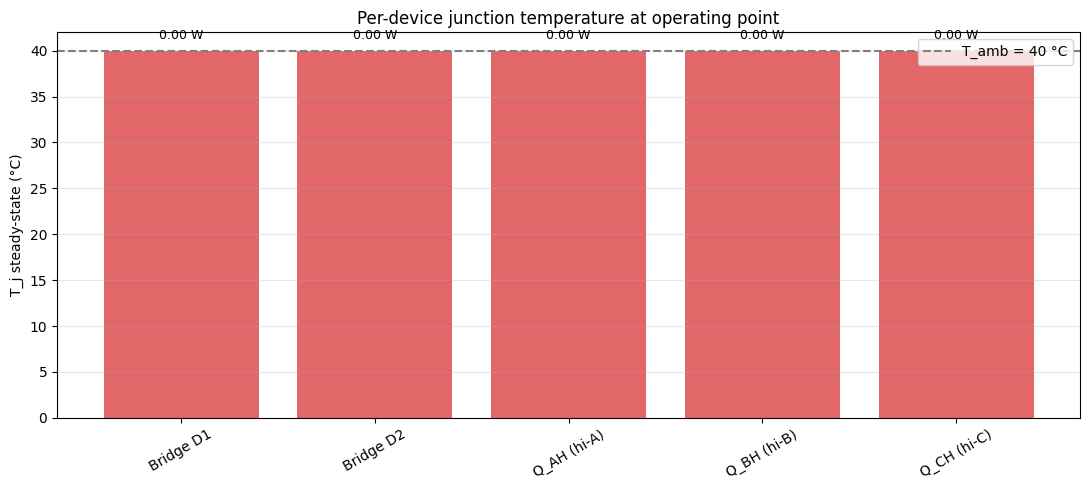

In [8]:
labels = [r[0] for r in rows if (r[5] == r[5] and r[5] > T_amb)]
tjs    = [r[5] for r in rows if (r[5] == r[5] and r[5] > T_amb)]
powers = [r[1] for r in rows if (r[5] == r[5] and r[5] > T_amb)]

fig, axL = plt.subplots(figsize=(11, 5))
bars = axL.bar(labels, tjs, color='#d62728', alpha=0.7)
axL.axhline(T_amb, color='grey', ls='--', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Per-device junction temperature at operating point')
axL.tick_params(axis='x', rotation=30)
axL.grid(alpha=0.3, axis='y')
axL.legend(loc='upper right')

# Annotate each bar with its dissipated power.
for bar, p in zip(bars, powers):
    axL.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{p:.2f} W', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
plt.show()

## Takeaways

- The single-phase utility feeds a 4-diode rectifier into a 470 µF bulk
  cap; the cap holds the DC link at ≈ 310 V with a 120 Hz ripple that
  bounded the inverter input.
- The 3-phase VSI synthesizes a balanced 3-phase output at 50 Hz with
  modulation index 0.8 — fundamental peak ≈ `m · V_dc ≈ 248 V`,
  delivering a per-phase RMS current ~ 14 A through 10 Ω.
- The unified loss + thermal pipeline reports per-device conduction
  and switching energy with **zero special wiring** — the user just
  populates the loss parameters at construction time and the runtime
  accumulates everything during the transient. Same accessor pattern
  (`<kind>_average_power`, `<kind>_steady_state_junction_temperature`)
  for diodes, MOSFETs, IGBTs, resistors, capacitors, and inductors.
- The auto-parasitics pre-flight runs invisibly and (correctly)
  doesn't act on this topology — there's no inductor in series with
  any inverter switch (the load L sits on the AC side, separated by
  the switch node, so the walker doesn't flag it). For an example
  where the analyser **does** act, see
  `12_boost_pfc_validation.py` — a 100 µH boost L upstream of the
  switch is exactly the pattern the analyser is looking for.